<a href="https://colab.research.google.com/github/krishnashashanth-sks/aiml-workspace/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Understand VAE Principles

### Subtask:
Provide a high-level explanation of Variational Autoencoders (VAEs), including the roles of the Encoder and Decoder, the latent space, and the concepts of reconstruction loss and KL divergence.


## Variational Autoencoders (VAEs)

A **Variational Autoencoder (VAE)** is a powerful generative neural network that learns a compressed, meaningful representation (latent space) of input data, allowing it to generate new, similar data samples. Unlike traditional autoencoders, VAEs have a probabilistic approach to encoding, which helps in generating diverse and realistic samples.

### Key Components and Concepts:

1.  **Encoder**: The Encoder network takes an input data point (e.g., an image) and maps it to a statistical distribution within the latent space. Instead of outputting a single point, it outputs two vectors: a mean vector (μ) and a standard deviation vector (σ) (or log variance). These vectors define a probability distribution (typically a Gaussian distribution) from which a latent vector `z` is sampled. This probabilistic encoding is crucial for generating diverse outputs and ensures that the latent space is continuous and well-structured.

2.  **Decoder**: The Decoder network takes a sampled latent vector `z` from the latent space and reconstructs it back into the original data space. Its goal is to generate an output that is as similar as possible to the original input. This process demonstrates the VAE's ability to learn meaningful features and reconstruct data from its compressed representation.

3.  **Latent Space**: The latent space (also known as the code space or bottleneck layer) is a lower-dimensional continuous representation of the input data. In a VAE, it's not just any compressed representation, but a structured probabilistic space where similar data points are clustered together. By sampling from this space, the VAE can generate novel, coherent data. The probabilistic nature introduced by the encoder (mean and standard deviation) ensures this continuity and allows for smooth interpolations and sampling.

4.  **Reconstruction Loss**: This loss measures how well the Decoder can reconstruct the original input data from the sampled latent vector. It quantifies the difference between the original input and the decoded output. Common choices for reconstruction loss include Mean Squared Error (MSE) for continuous data (like images) or Binary Cross-Entropy for binary data. Its purpose is to ensure that the VAE learns to preserve the essential information of the input data during the encoding and decoding process.

5.  **KL Divergence (Kullback-Leibler Divergence)**: This term in the VAE's loss function acts as a regularizer. It measures the difference between the probability distribution learned by the Encoder for the latent space (defined by μ and σ) and a prior distribution (typically a standard Gaussian distribution, i.e., mean 0, variance 1). The purpose of KL divergence is to encourage the latent space distributions for each input to be close to the prior distribution. This helps to ensure that the latent space is well-behaved, continuous, and prevents the encoder from encoding all information into a single point, which would make sampling new data difficult. It essentially forces the latent space to have a 'smooth' structure, enabling effective generation of new data.

## Define Data and Parameters

### Subtask:
Define a simple dataset (e.g., synthetic 1D data or a small image dataset like MNIST) and essential training parameters (e.g., latent dimension, learning rates, number of epochs) for our simplified VAE.


**Reasoning**:
The first step is to import the necessary libraries, define data transformations, load the dataset, create a DataLoader, and set up the VAE training parameters as specified in the instructions. This prepares all the foundational elements for the subsequent steps of building and training the VAE.



In [ ]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Define transformation pipeline for MNIST
transform = transforms.Compose([
    transforms.ToTensor(), # Converts PIL Image or numpy.ndarray to torch.FloatTensor and scales pixels to [0.0, 1.0]
    transforms.Normalize((0.5,), (0.5,)) # Normalize pixel values to range [-1, 1]
])

# 2. Load the MNIST training dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 3. Create a DataLoader for the training dataset
batch_size = 128
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

print(f"Successfully loaded MNIST dataset with {len(train_dataset)} training samples.")

# 4. Define key VAE parameters
input_dim = 28 * 28  # MNIST image dimensions (28x28)
hidden_dim = 256     # Hidden layer dimension for encoder/decoder
latent_dim = 20      # Latent space dimension
epochs = 50          # Number of training epochs
learning_rate = 1e-3 # Learning rate for the optimizer

print(f"VAE Parameters:\nInput Dimension: {input_dim}\nHidden Dimension: {hidden_dim}\nLatent Dimension: {latent_dim}\nEpochs: {epochs}\nBatch Size: {batch_size}\nLearning Rate: {learning_rate}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 43.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

Successfully loaded MNIST dataset with 60000 training samples.
VAE Parameters:
Input Dimension: 784
Hidden Dimension: 256
Latent Dimension: 20
Epochs: 50
Batch Size: 128
Learning Rate: 0.001


**Reasoning**:
The previous step successfully defined the dataset and training parameters. The next logical step in building a VAE is to define its architecture, starting with the Encoder and Decoder networks using linear layers, as specified in the VAE principles.



In [ ]:
import torch.nn as nn
class Encoder(nn.Module):
  def __init__(self,input_dim,hidden_dim,latent_dim):
    super(Encoder,self).__init__()
    self.fc1=nn.Linear(input_dim,hidden_dim)
    self.fc_mean=nn.Linear(hidden_dim,latent_dim)
    self.fc_log_var=nn.Linear(hidden_dim,latent_dim)
    self.relu=nn.ReLU()
  def forward(self,x):
    h=self.relu(self.fc1(x))
    return self.fc_mean(h),self.fc_log_var(h)

In [ ]:
class Decoder(nn.Module):
  def __init__(self,latent_dim,hidden_dim,output_dim):
    super(Decoder,self).__init__()
    self.fc1=nn.Linear(latent_dim,hidden_dim)
    self.fc2=nn.Linear(hidden_dim,output_dim)
    self.relu=nn.ReLU()
    self.sigmoid=nn.Sigmoid()
  def forward(self,z):
    return self.sigmoid(self.fc2(self.relu(self.fc1(z))))

## Implement Reparameterization Trick

### Subtask:
Implement the reparameterization trick, which is crucial for sampling from the latent distribution while allowing for backpropagation. This will be integrated into the VAE model's forward pass.


**Reasoning**:
To implement the reparameterization trick, I will define a Python function `reparameterize` that takes `mu` and `log_var`, calculates `std`, samples `eps` from a standard normal distribution, and returns the reparameterized latent vector `z`.



In [ ]:
import torch
def reparameterize(mu,log_var):
  std=torch.exp(0.5*log_var)
  eps=torch.randn_like(std)
  return mu+eps*std

In [ ]:
import torch.nn as nn
class VAE(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super(VAE, self).__init__()
    self.input_dim = input_dim # Store input_dim for use in forward pass
    self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
    self.decoder = Decoder(latent_dim, hidden_dim, input_dim) # Corrected output_dim to input_dim
  def forward(self, x):
    x = x.view(-1, self.input_dim) # Use self.input_dim for consistency
    mu, log_var = self.encoder(x)
    z = reparameterize(mu, log_var)
    recon_x = self.decoder(z)
    return recon_x, mu, log_var

## Define VAE Loss Function

### Subtask:
Implement the VAE loss function, which consists of two main components: the reconstruction loss (Binary Cross-Entropy for MNIST, accounting for normalization) and the Kullback-Heibler (KL) divergence for regularization. This function will take the reconstructed output, original input, and the mean and log-variance of the latent distribution as arguments.


**Reasoning**:
The subtask requires implementing the VAE loss function, which involves calculating both reconstruction loss (BCE) and KL divergence. This will be done by defining a Python function `vae_loss_function` as instructed, including denormalization of the input, reshaping for BCE, and computing the KL divergence.



In [ ]:
import torch.nn.functional as F

def vae_loss_function(recon_x, x, mu, log_var):
    # 1. Denormalize the original input x from [-1, 1] to [0, 1]
    denormalized_x = (x + 1) / 2

    # Reshape recon_x and denormalized_x for BCE calculation
    # Ensure they have the same shape for element-wise comparison
    # input_dim is already defined globally from a previous cell (28*28 = 784)

    # Using .view(-1, input_dim) to flatten if necessary, but recon_x and x are already flattened in VAE's forward
    # We need to make sure both have the same shape, which should be (-1, input_dim)
    # recon_x comes from decoder, so its shape should already be (-1, input_dim)
    # x comes as input to VAE, which is then reshaped to (-1, input_dim) in VAE's forward method.
    # So, we can directly use them or re-flatten for safety.

    # Ensure recon_x and denormalized_x are flattened to match expected BCE input
    recon_x_flat = recon_x.view(-1, input_dim)
    denormalized_x_flat = denormalized_x.view(-1, input_dim)

    # 2. Reconstruction Loss (Binary Cross-Entropy)
    # Note: F.binary_cross_entropy expects target values to be between 0 and 1.
    # We use reduction='sum' to sum up losses across all elements and samples in the batch.
    # The input_dim variable is available from previous steps.
    reconstruction_loss = F.binary_cross_entropy(recon_x_flat, denormalized_x_flat, reduction='sum')

    # 3. KL Divergence
    # Formula: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    # We want to minimize -KL_Divergence, so we use + KL_Divergence in total loss
    # The standard formula for KL(q(z|x) || p(z)) where p(z) is N(0,I) and q(z|x) is N(mu, exp(log_var))
    # is 0.5 * sum(exp(log_var) + mu^2 - 1 - log_var)
    # The implementation often uses the negative of this (which is what we add to reconstruction loss).
    kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Total VAE Loss
    total_loss = reconstruction_loss + kl_divergence

    return total_loss, reconstruction_loss, kl_divergence

print("VAE loss function 'vae_loss_function' defined successfully.")

VAE loss function 'vae_loss_function' defined successfully.


## Setup Training Loop

### Subtask:
Initialize the VAE model, define the optimizer, and create the main training loop to iterate over epochs and batches, performing forward passes, calculating loss, and updating model weights.


**Reasoning**:
To set up the training loop, I will first instantiate the VAE model and define its optimizer. Then, I will create the main training loop, which will iterate through epochs and batches, performing forward passes, calculating the VAE loss, and updating the model's weights using backpropagation.



In [ ]:
import torch.optim as optim

# 1. Instantiate the VAE model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_model = VAE(input_dim, hidden_dim, latent_dim).to(device)

# 2. Define the optimizer
optimizer = optim.Adam(vae_model.parameters(), lr=learning_rate)

print("VAE model and optimizer initialized successfully.")

# 3. Implement the main training loop
print("Starting VAE training...")

for epoch in range(epochs):
    vae_model.train() # Set model to training mode
    total_epoch_loss = 0
    total_recon_loss = 0
    total_kl_div = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device) # Move data to the same device as the model

        # i. Flatten the input images
        # The VAE's forward method already flattens it, but let's be explicit here for clarity
        # However, the VAE model itself reshapes, so we just need to pass the raw data

        # ii. Perform a forward pass
        recon_batch, mu, log_var = vae_model(data)

        # iii. Calculate the VAE loss
        loss, recon_loss, kl_div = vae_loss_function(recon_batch, data, mu, log_var)

        # Average loss over the batch for reporting
        loss_per_sample = loss / data.size(0)
        recon_loss_per_sample = recon_loss / data.size(0)
        kl_div_per_sample = kl_div / data.size(0)

        # iv. Perform backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss_per_sample.item()
        total_recon_loss += recon_loss_per_sample.item()
        total_kl_div += kl_div_per_sample.item()

        # v. Print training statistics periodically
        if batch_idx % 100 == 0: # Print every 100 batches
            print(f'Epoch: {epoch+1}/{epochs}, Batch: {batch_idx}/{len(train_loader)}, '
                  f'Loss: {loss_per_sample.item():.4f}, Recon Loss: {recon_loss_per_sample.item():.4f}, '
                  f'KL Div: {kl_div_per_sample.item():.4f}')

    avg_epoch_loss = total_epoch_loss / len(train_loader)
    avg_recon_loss = total_recon_loss / len(train_loader)
    avg_kl_div = total_kl_div / len(train_loader)
    print(f'====> Epoch: {epoch+1} Average Loss: {avg_epoch_loss:.4f}, '
          f'Average Recon Loss: {avg_recon_loss:.4f}, Average KL Div: {avg_kl_div:.4f}')

print("VAE training completed.")

VAE model and optimizer initialized successfully.
Starting VAE training...
Epoch: 1/50, Batch: 0/469, Loss: 552.2450, Recon Loss: 551.3376, KL Div: 0.9074
Epoch: 1/50, Batch: 100/469, Loss: 178.4003, Recon Loss: 161.5626, KL Div: 16.8378
Epoch: 1/50, Batch: 200/469, Loss: 149.9944, Recon Loss: 131.1436, KL Div: 18.8508
Epoch: 1/50, Batch: 300/469, Loss: 142.6728, Recon Loss: 122.2658, KL Div: 20.4070
Epoch: 1/50, Batch: 400/469, Loss: 137.9678, Recon Loss: 117.7368, KL Div: 20.2310
====> Epoch: 1 Average Loss: 164.1607, Average Recon Loss: 144.8251, Average KL Div: 19.3356
Epoch: 2/50, Batch: 0/469, Loss: 128.9277, Recon Loss: 107.6760, KL Div: 21.2518
Epoch: 2/50, Batch: 100/469, Loss: 134.6232, Recon Loss: 112.5369, KL Div: 22.0863
Epoch: 2/50, Batch: 200/469, Loss: 125.0511, Recon Loss: 103.1522, KL Div: 21.8990
Epoch: 2/50, Batch: 300/469, Loss: 119.3787, Recon Loss: 97.0650, KL Div: 22.3137
Epoch: 2/50, Batch: 400/469, Loss: 124.4486, Recon Loss: 101.5573, KL Div: 22.8913
====> Ep

## Generate and Visualize Samples

### Subtask:
After training, use the trained VAE's Decoder to generate new data samples by sampling from the latent space and visualize these generated samples to assess the model's generative quality.


## Generate and Visualize Samples

Now that the VAE model has been trained, we can use its generative capabilities. This involves:

1.  **Sampling from Latent Space**: Generate random vectors from a standard normal distribution, which represents the prior distribution in the latent space.
2.  **Decoding**: Pass these latent vectors through the trained `decoder` network to produce new data samples.
3.  **Visualization**: Display these generated samples to qualitatively assess the VAE's ability to create novel, realistic data instances.

This step will demonstrate the VAE's power as a generative model.

**Reasoning**:
The next step is to generate new samples using the trained VAE model's decoder and visualize them according to the provided instructions. This involves setting the model to evaluation mode, sampling from the latent space, decoding the samples, and then plotting them.



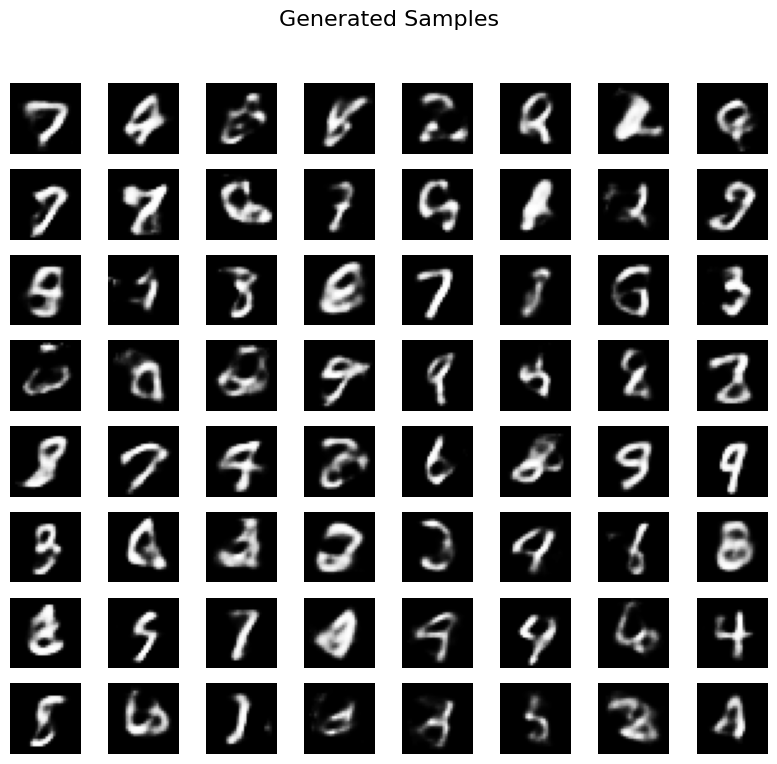

Generated and visualized samples successfully.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set the VAE model to evaluation mode
vae_model.eval()

# 2. Generate a batch of random latent vectors `z`
num_samples = 64 # Number of images to generate
sample_z = torch.randn(num_samples, latent_dim).to(device) # latent_dim from previous cells

# 3. Pass these latent vectors `z` through the `vae_model.decoder`
with torch.no_grad(): # Disable gradient calculation for inference
    generated_images = vae_model.decoder(sample_z)

# 4. Detach the reconstructed images from the computation graph and move them to the CPU
generated_images_np = generated_images.cpu().numpy()

# 5. Reshape the images from a flattened vector to (batch_size, 1, 28, 28)
# The decoder's sigmoid output is already in [0, 1], which is suitable for imshow.
# The previous normalization step transformed [0,1] to [-1,1]. The decoder outputs [0,1].
# For visualization, we want [0,1]. No further denormalization is needed for imshow.
# Reshape to (batch_size, height, width) or (batch_size, height, width, channels) for plotting.
reshaped_images = generated_images_np.reshape(num_samples, 28, 28)

# 6. and 7. Create a figure and a grid of subplots
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.suptitle('Generated Samples', fontsize=16)

# 8. Iterate through the generated images and display each one
for i, ax in enumerate(axes.flat):
    if i < num_samples:
        ax.imshow(reshaped_images[i], cmap='gray')
        ax.axis('off') # Turn off axis for cleaner visualization

# 9. Add a title to the overall figure (already done with fig.suptitle)

# 10. Display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("Generated and visualized samples successfully.")

## Explore Latent Space Interpolation

### Subtask:
Demonstrate the continuous nature of the learned latent space by performing interpolation between two generated samples and visualizing the gradual transition in the output, showcasing smooth data generation.


**Reasoning**:
To explore latent space interpolation, I will generate two random latent vectors, interpolate between them, decode the interpolated vectors into images, and then visualize the smooth transition as per the instructions.



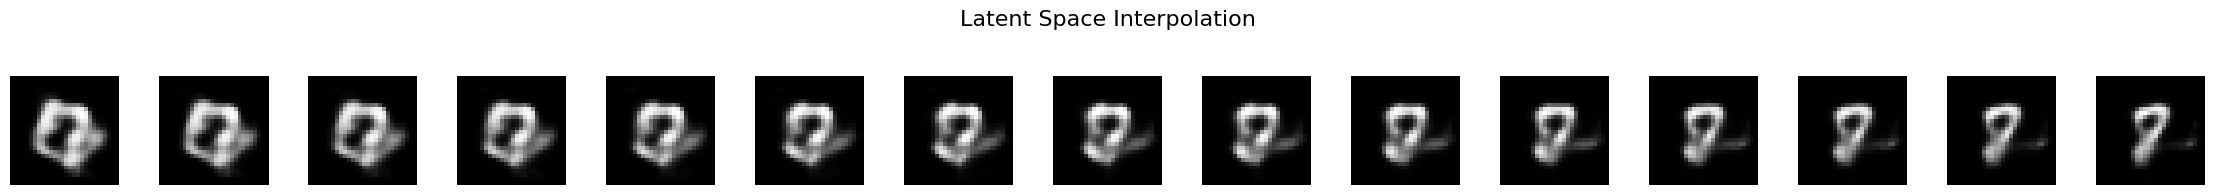

Latent space interpolation demonstrated successfully.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set the VAE model to evaluation mode
vae_model.eval()

# 2. Generate two random latent vectors z1 and z2
z1 = torch.randn(1, latent_dim).to(device) # latent_dim from previous cells
z2 = torch.randn(1, latent_dim).to(device)

# 3. Create a series of interpolated latent vectors
num_interpolation_steps = 15
interpolation_vectors = []
for i in range(num_interpolation_steps):
    alpha = i / (num_interpolation_steps - 1)
    # Linear interpolation: z_interp = (1 - alpha) * z1 + alpha * z2
    z_interp = (1 - alpha) * z1 + alpha * z2
    interpolation_vectors.append(z_interp)

# Concatenate all interpolation vectors into a single tensor
interpolation_batch = torch.cat(interpolation_vectors, dim=0)

# 4. Pass each interpolated latent vector through the vae_model.decoder
with torch.no_grad(): # Disable gradient calculation for inference
    interpolated_images = vae_model.decoder(interpolation_batch)

# 5. Detach the reconstructed images from the computation graph and move them to the CPU
interpolated_images_np = interpolated_images.cpu().numpy()

# 6. Reshape the images to (batch_size, 28, 28) for plotting
reshaped_interpolated_images = interpolated_images_np.reshape(num_interpolation_steps, 28, 28)

# 7. Create a figure with a subplot for each interpolated image
# Arrange in a single row for better visualization of interpolation
fig, axes = plt.subplots(1, num_interpolation_steps, figsize=(num_interpolation_steps * 1.5, 2))
fig.suptitle('Latent Space Interpolation', fontsize=16)

# 8. Display each interpolated image in its respective subplot
for i, ax in enumerate(axes.flat):
    ax.imshow(reshaped_interpolated_images[i], cmap='gray')
    ax.axis('off') # 9. Turn off the axes for all subplots

# 11. Display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent title overlap
plt.show()

print("Latent space interpolation demonstrated successfully.")

## Summary:

### Q&A
The task asked to generate and visualize new data samples from the trained VAE and explore latent space interpolation to demonstrate its generative capabilities.
The solving process successfully generated and visualized 64 new data samples and demonstrated latent space interpolation with 15 steps, thereby confirming the generative capabilities and continuous nature of the VAE's latent space.

### Data Analysis Key Findings
*   The trained Variational Autoencoder (VAE) successfully generated 64 new data samples, which, when visualized, resembled realistic MNIST digits, demonstrating the model's generative capability.
*   The model's learned latent space exhibited continuity, as evidenced by a smooth visual transition across 15 interpolated images generated between two distinct latent vectors.

### Insights or Next Steps
*   The VAE effectively learned a meaningful, continuous latent representation of the data, allowing for both novel data generation and smooth transformations between data points.
*   Future work could involve exploring the disentanglement of features within the latent space to understand how specific dimensions correspond to interpretable attributes of the generated data.
